In [73]:
import seaborn as sns
import numpy as numpy
import matplotlib.pyplot as plt

sns.set_theme(context='notebook', style='darkgrid')

## Filters For Dummies Pt. 1

These are my notes. I am a dummy trying to learn about filters, with the eventual goal of implementing them in code.

I want to write down the things I am learning in the way that I would like to have been taught them, but never was. Math in school was usually taught as absract, memorized equations forced down my throat, and with no demonstrated application. I'm going back and learning the intuition long after graduation because now I want to apply the math I learned to real world problems. I hope this helps future me and other dummies, too. 

# Linear Algebra Building Blocks
The first few sections are just to remind me of the basic linear algebra and probability theory needed to understand Kalman filters intuitively. Nothing too deep, just some basic definitions.

## The Dot Product

Given two vectors

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
,
\qquad
z =
\begin{bmatrix}
z_1 \\
z_2
\end{bmatrix}
,
$$
 

$$
z^T x
=
z_1x_1 + z_2x_2.
$$

The result of the dot product is a scalar that encapsulates or encodes both the angle between the two vectors and their magnitudes. To see this more clearly, the dot product can also be written as

$$
a \cdot b = \lVert a \rVert \lVert b \rVert \cos{\theta}
$$

Where $\theta$ is the angle between the vectors $a$ and $b$. 

### Dot Product as a Projection

This is why dot products are important to our discussion, so pay attention to this geometric intuition. 

$$\frac{a \cdot b}{\lVert a \rVert}$$

gives the magnitude of the projection of $b$ in the direction of $a$. To illustrate what this means, a set of random points in 2-D space are created. We take the dot product of each point's vector with the unit vector $z = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ (shown in blue below) to obtain their projected positions along $z$:


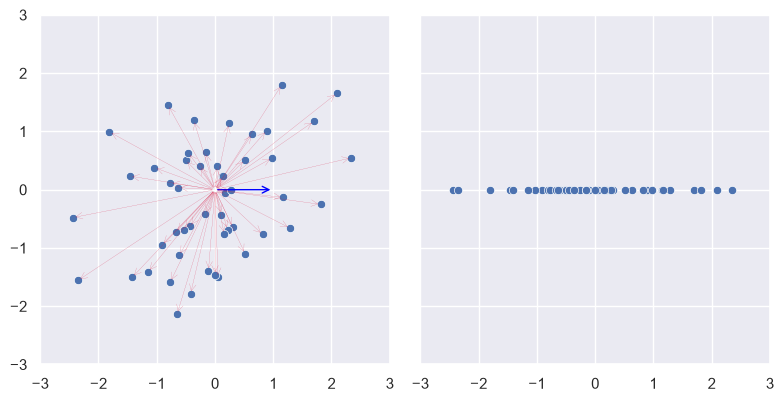

Notice that the dot product of each point with $z$ is just point's $x$ coordinate. That is because we chose $z$ to point along the x-axis. 

Also note that we don't need to divide by the magnitude of $z$ because it is already of length 1, so it will have no effect. 

## Transformations, Coordinate Systems, and Basis Vectors

The goal of this section is to understand what a matrix actually represents. A matrix encodes a transformation of a vector existing in a specific coordinate system. A matrix is simply one way of describing that transformation.

To see why this distinction matters, consider a simple example. Imagine a vector in two-dimensional space:

$$
x =
\begin{bmatrix}
1 \
2
\end{bmatrix}.
$$

Now suppose we apply a transformation that stretches every vector horizontally by a factor of two while leaving the vertical direction unchanged. Geometrically, this transformation takes

$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\rightarrow
\begin{bmatrix}
2 \\
2
\end{bmatrix}
$$

The transformation itself is the geometric action of stretching the space. Once we choose a coordinate system, we can represent that transformation using a matrix:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
$$

Applying the matrix gives

$$
Ax =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
1 \\
2
\end{bmatrix}
=
\begin{bmatrix}
2 \\
2
\end{bmatrix}
$$

### Basis Vectors 

The matrix is therefore not the stretch itself. It is a bookkeeping device that tells us how the stretch affects vectors expressed in a particular coordinate system. This raises an important question: what exactly is a coordinate system? A coordinate system begins with a collection of basis vectors. In two dimensions, the standard basis is

$$
e_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix},
\qquad
e_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}.
$$

These vectors define the horizontal and vertical directions. Due to the vectors being linearly independent, any vector in the plane can be written as a weighted sum of these basis vectors. For example,

$$
x =
\begin{bmatrix}
3 \\
4
\end{bmatrix}
=
3e_1 + 4e_2
$$

The coordinates (3,4) do not just define the vector. They also tell us how much of the vector exists along each basis directions in the chosen coordinate system defined by $e_1$ and $e_2$. This distinction is subtle but important. To further illustrate this subtlety, imagine describing a location on Earth. One person might use latitude and longitude. Another might use a local north-east coordinate frame. A third might use coordinates attached to a moving vehicle. The numerical coordinates differ, but the physical location remains the same.

Vectors behave similarly. The geometric vector exists independently of the coordinate system used to describe it. This observation leads to an important consequence. If the basis changes, the coordinates of a vector generally change as well.

### Change of Basis

Suppose we choose a new basis:

$$
v_1 =
\begin{bmatrix}
1 \\
1
\end{bmatrix},
\qquad
v_2 =
\begin{bmatrix}
-1 \\
1
\end{bmatrix}.
$$

These vectors are not aligned with the standard horizontal and vertical directions. They define a new coordinate system. The geometric vector

$$
x =
\begin{bmatrix}
3 \\
4
\end{bmatrix}
$$

has not changed. It still represents the same displacement in the plane. However, its coordinates in the new basis will generally be different. To find those coordinates, we express the vector $x$ as a linear combination of the new basis vectors:

$$
x = av_1 + bv_2.
$$

In the standard basis, the coordinates associated with $x$ were the same as the values of the vector $x$ itself.

$$
\begin{bmatrix}
3 \\
4
\end{bmatrix}
$$

Solving for $a$ and $b$ with the new basis gives us the coordinates of $x$ in the new coordinate system:

$$
\begin{bmatrix}
\frac{7}{2} \\
\frac{1}{2}
\end{bmatrix}
$$

Notice that the coordinates have changed, but the geometric object, the vector $ \begin{bmatrix} 3 \\ 4 \end{bmatrix}$ has not. Both coordinate representations describe exactly the same object. The only thing that changed was the basis and thereby the coordinate system. This distinction is crucial because transformations and covariance matrices are geometric objects. Their matrix representations depend on the chosen basis, but the underlying geometry does not. Later, we will discover that covariance matrices possess special directions called principal components. These directions are not artifacts of a coordinate system. They are intrinsic properties of the uncertainty itself. Understanding that fact requires first understanding the difference between a geometric object and the coordinates used to describe it.

### Summary

The key ideas from this section are therefore:

1. The transformation is the important object. A matrix is merely a representation of that transformation in a particular, chosen coordinate system. If you change the coordinate system, the matrix representation can change, but the transformation it performs will not.
2. A vector is a geometric object. Coordinates are a description of that object relative to a basis.
3. Like matrices, changing coordinates changes the numerical representation but not the underlying geometry.

These ideas may seem abstract for now, but they provide the foundation for understanding eigenvectors, covariance matrices, and eventually the geometry of uncertainty.

## Eigenvectors and Eigenvalues

In the previous section, we established that a matrix represents a transformation. Given a vector $x$, applying a matrix $M$ produces a new vector we will call $y$.

$$
Mx = y
$$

In general, a transformation changes both the magnitude and direction of a vector. A stretch, rotation, or shear may completely change the orientation of the original vector.

 An **eigenvector** $v$ of a matrix $M$ is one such that

$$
Mv = \lambda v
$$

We can see that the resulting transformation is just a scaling of the original vector $v$ by some scalar value $\lambda$. That scalar value is called an **eigenvalue**. The direction of the vector has not changed, only its magnitude has. 

### Geometric Interpretation

Eigenvectors tell us **where** the transformation acts, while the eigenvalues tell us **how strongly** it acts in those directions. In order to see this more clearly, we must do a little bit of algebra (sorry). The significance of eigenvectors becomes clearer when we 

1. Remember that any vector can be expressed as a linear combination of basis vectors, as described in the last section.
2. Consider that symmetric matrices, in which we are interested for this application, possess eigenvectors that are linearly independent and therefore form a set of basis vectors.

With these facts in hand we can write any vector $x$ as the linear combination of the basis vectors (eigenvectors $v_1 \dots v_n$ ):

$$
x = a_1v_1 + a_2v_2 + \cdots + a_nv_n.
$$

Then, applying the transformation gives

$$
Mx
=
M(a_1v_1 + a_2v_2 + \cdots + a_nv_n).
$$

Then, using the fact that the transformation is linear we can rewrite that as

$$
Mx
=
a_1Mv_1 + a_2Mv_2 + \cdots + a_nMv_n.
$$

Substituting the eigenvector relation $Mv_i=\lambda_i v_i$ yields

$$
Mx
=
a_1\lambda_1 v_1
+
a_2\lambda_2 v_2
+
\cdots
+
a_n\lambda_n v_n.
$$

This result provides an important geometric interpretation of eigenvectors and eigenvalues. The eigenvectors define the natural directions of the transformation. The coefficients $a_i$ tell us how much of the original vector exists along each of those directions. The eigenvalues then scale those components independently.

In other words, if we express a vector in the eigenvector basis, the transformation becomes remarkably simple. Each component is merely multiplied by its corresponding eigenvalue. This idea will become extremely important when we discuss covariance matrices. We will eventually see that the eigenvectors of a covariance matrix correspond to the principal directions of uncertainty, while the eigenvalues correspond to the variances along those directions.

### A Note On Symmetric Matrices

In the previous section, we briefly mentioned the dependency on symmetric matrices for the explanation of eigenvalues and eigenvectors as geometrical characterizations of a matrix transformation.

A matrix is symmetric if

$$
M = M^T.
$$

More importantly for our purpose, a symmetric matrix possesses an eigenbasis (a set of linearly independent eigenvectors). Therefore, any vector $x$ can be expressed as a linear combination of the eigenvectors that form that eigenbasis.

$$
x = a_1v_1 + a_2v_2 + \cdots + a_nv_n,
$$

then the coefficients $a_i$ describe how much of the vector exists along each eigenvector direction. Applying the transformation simply scales those components according to the corresponding eigenvalues. As a result, every symmetric matrix can be understood as a collection of independent stretchings and compressions along mutually perpendicular directions. The eigenvectors specify the directions, and the eigenvalues specify the amount of scaling along each direction, as we saw in the last section.

# Probability Building Blocks
Like the last major section, we are going to perform a review of some basic concepts, this time in probability. 

1. review some basic probability that will help our intuition with filters.
2. We will also bridge the gap between probability and the geometric interpretations of matrix transformations discussed in the last section.

The review of these topics will hopefully be enough to form an intuition that will help in learning about Kalman filters. 

## Random Vectors and Covariance Matrices

A random vector in probability theory is one in which 

1. Each element $x_i$ of the vector is a random variable with its own probability distribution. These individual univariate distributions are called the marginal distributions.
2. The random vector, $X$, itself follows a joint probability, also known as a multivariate probability. 

$$
X =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}.
$$

Uncertainty within a univariate or marginal probability is characterized as variance, described by

$$
Var(x) = E[(x - \mu)^2]
$$

where x is a scalar random variable and $\mu$ is the scalar mean of the distribution of that variable. 

Likewise, the uncertainty of a multivariate or joint probability is characterized by a covariance matrix, of which variance is actually just a special, one dimensional case. Covariance extends the same idea to multiple dimensions. Instead of measuring uncertainty along a single axis, it measures how uncertainty is distributed throughout the state space. The covariance of a random vector $X$ is defined as
<br><br>
$$
Cov(X) = \Sigma = E[(X-\mu)(X-\mu)^T]
$$
<br>
Because $X$ and $\mu$ are vectors, the quantity $X−\mu$ is a deviation vector. The covariance matrix is therefore the average outer product of the deviation vectors. Each deviation vector contributes information about both the direction and magnitude of a deviation from the mean. Averaging these outer products produces a matrix that characterizes how uncertainty is distributed throughout the state space. Importantly, it is a symmetric matrix and therefore contains an linearly independent set of eigenvectors that form a basis.

One further note, that will become useful soon is that symmetric matrices possess eigenvectors that are not just linearly independent, but are also mutually perpendicular (a.k.a. orthogonal). 

## The Shape of Uncertainty

In the previous section, we saw that the covariance matrix is a symmetric matrix formed by averaging the outer products of deviation vectors:

$$
\Sigma = E[(X-\mu)(X-\mu)^T].
$$

Because covariance is a symmetric matrix, it possesses an eigenbasis. We therefore expect its eigenvectors and eigenvalues to provide a geometric characterization of uncertainty in much the same way that they characterized the action of a general transformation matrix.

To understand what these eigenvectors represent, imagine repeatedly sampling from a two-dimensional distribution and plotting the resulting points. If the uncertainty is identical in every direction, the distribution may appear roughly circular. However, many real distributions are not circular. Instead, they tend to be elongated along certain directions. For example, a distribution might look roughly elliptical:

<div align="center">
    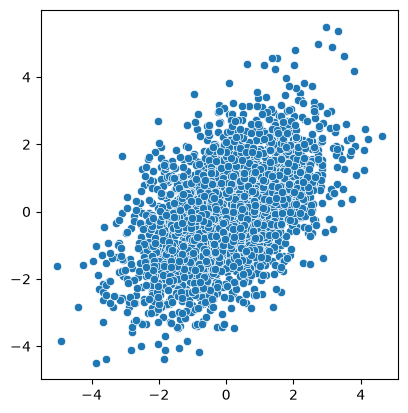
</div>

Notice that the uncertainty is not distributed equally in all directions. It is elliptical in nature, and you may recall that ellipses have a major and a minor axis. The eigenvectors of the covariance matrix characterize the principal directions of uncertainty, which are the major and minor axis of the ellipse formed by the uncertainty. Mean while, the eigenvalues quantify the amount of uncertainty along those directions. This is directly analoguous to our geometric explanation of how eigenvectors dictate the direction of transformation while the eigenvalues specify the magnitude.

The data above was sampled from a distribution with a covariance matrix $\Sigma = \begin{bmatrix}2 & 1 \\1 & 2\end{bmatrix}$, which has eigenvalues $\lambda_1 = 3$ and $\lambda_2 = 1$ with normalized eigenvectors

$$
v_1 = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}, v_2 = \begin{bmatrix} -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}
$$

After scaling the eigenvectors by their corresponding eigenvalues and overlaying them on the sample plot, we see exactly what we would expect based on our geometric intuition of eigenvalues and eigenvectors:

<div align="center">
    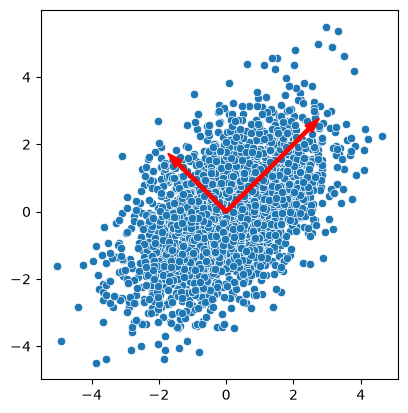
</div>


In [ ]:
# Code:
mean = [0, 0]
cov = [[2, 1], 
       [1, 2]]

x = np.random.multivariate_normal(mean, cov, size=2500)
ax = sns.scatterplot(x=x[:, 0], y=x[:, 1])

evals, evecs = np.linalg.eig(cov)
for i, l in enumerate(evals):
    v = evecs[:, i]

    ax.arrow(
        mean[0], 
        mean[1], 
        v[0] * np.sqrt(l) * 2,
        v[1] * np.sqrt(l) * 2, 
        color="red",
        width=0.1
    )
    
ax.set_aspect('equal');

## An Experiment to Confirm Our Beliefs

An interesting experiment is to 

1. Compute the projection of every sampled point onto the first and second principal axis (this is why we studied dot products in the first section)
2. Note that the projected points now lie on a 1-D line
3. Recall that Covariance in 1-D space is just Variance (something we discussed in the second section).
4. Compute the variance of the projected points

If our understanding is correct, we should see that the variance of each projection should be roughly equal to our eigenvalues $\lambda_1=3$ and $\lambda_2=1$

Mathematically, we are taking the variance of two new random variables derived as the projection of $X$ onto each of the eigenvectors:

$$
\begin{align}
y &= X \cdot v_1 \\
z &= X \cdot v_2
\end{align}
$$

****Note:** that we do not need to divide by the magnitude of our eigenvectors because they are already unit vectors. They are normalized for us by the NumPy algorithm we used to calculate the eigen values and vectors. 

Then, we compute the variance $Var(y)$ and $Var(z)$ and see if their values match our eigenvalues. Recall that the formula for variance of a random variable is:

$$
Var(y) = \mathbb{E}[(y - \mu_y)^2]
$$

Where $\mu_y$ is the mean value of $y$. But we will just compute the result with python below:

$$Var(y) = 3.0422, Var(z) = 1.0283$$

Which is very close to the values of our eigenvalues. 

In [ ]:
# Broadcast dot product across all sample points
y_1 = np.dot(x, evecs[:, 0])
y_2 = np.dot(x, evecs[:, 1])

# Print variance of each of the two projections
# print(f"\nVariance of projection along first axis: {np.var(y_1)}")
# print(f"Variance of projection along second axis: {np.var(y_2)}")

## Uncertainty in a Direction

We might wish to know what the uncertainty in any direction is. You may have guessed that the uncertainty along the eigenvectors of the distribution is the values of their corresponding eigenvalues. We will present an optional proof of that fact below, but for now let's talk about how we can measure uncertainty in an arbitrary direction. We will again leverage the geometric interpretations of dot products as projections. 

In the example below, we have sparsely sampled a distribution so that it is easier to visualize the vectors associated with the sampled points.

The blue vector, we will call it $z=\begin{bmatrix} 1 \\ 0 \end{bmatrix}$, represents the direction in which we wish to measure uncertainty. It is a unit vector along the horizontal axis. We will take the dot product of each sample vector $x_i$ with $z$ to project each point onto the horizontal axis:

$$
y_i = x_i \cdot z
$$

<div align="center">
    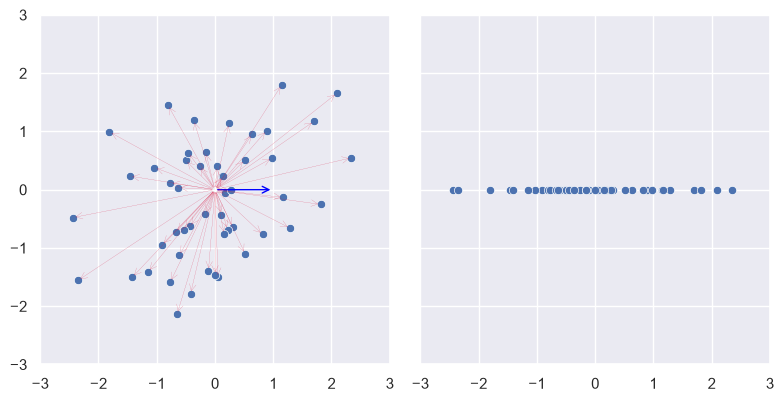<br><br>

Then, we simply compute the variance of these points:

$$
Var(y) = \mathbb{E}[(y - \mu_y)^2]
$$

In [ ]:
# Code:

import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)

cov = [[1,0.5],[0.5, 1]]
z = np.asarray([1, 0],)
x = np.random.multivariate_normal(mean, cov, size=50)

sns.scatterplot(x=x[:, 0], y=x[:, 1], ax=ax1)
ax1.annotate("", xytext=(0, 0), xy=(1, 0), arrowprops=dict(arrowstyle="->", color='blue'))
for point in x:
    ax1.annotate("", xytext=(0, 0), xy=point, arrowprops=dict(arrowstyle="->", color='crimson', linewidth=0.1))

projected_points = np.dot(x, z)
sns.scatterplot(x=projected_points, y=np.zeros_like(projected_points), ax=ax2)

for ax in (ax1, ax2):
    ax.set_ylim(bottom=-3, top=3)
    ax.set_xlim(left=-3, right=3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Compact Formula of Directional Uncertainty

The uncertainty in a direction can be computed more simply. If we define a new random variable $y = X \cdot z$, which is the random variable $X$ projected onto the line of the unit vector $z$, representing the direction we wish to measure uncertainty in, then

$$
Cov(y) = z^T\Sigma z
$$

Using this compact formula, we can quickly show that the eigenvalues of $\Sigma$ are the directional uncertainty along the normalized eigenvectors. You may have already guessed this, but here we show it:

$$
\begin{align}
v^T \Sigma v &= v^T \lambda v \\
&= \lambda v^Tv \\
&= \lambda \lVert v \rVert \\
&= \lambda
\end{align}
$$

Below I provide the proof of the formula, but it's really just a brain teaser I used to remind myself I can still do math, and is not important to learning about filters.

### Optional Proof of $Cov(y) = z^T\Sigma z$

Let $y$ be a random variable derived as

$$
y = X \cdot z
$$

Then, compute the variance of $y$ by the standard definition:

$$
\begin{align}
Var(y) &=\mathbb{E}[(y - \mu_y)^2] \\
&= \mathbb{E}[(X \cdot z - \mu_y)^2]
\end{align}
$$

Now, we will utilize the fact that mean value of a projection $y = X \cdot z$ is the just the mean of $X$ projected onto $z$. Specifically

$$
\mu_y = \mu_X \cdot z
$$

With that, we substitute and perform a series of algebraic (I hate algebra!) manipulations that leverage

1. Converting dot products to matrix multiplication: $a \cdot b = a^T b$
2. Apply the associative rule of matrix multiplication: (AB)C = A(BC). 

$$
\begin{align}
\mathbb{E}[(X \cdot z - \mu_y)^2] &= \mathbb{E}[(X \cdot z - \mu_X \cdot z)^2] \\
&= \mathbb{E}[((X  - \mu_X) \cdot z)^2] \\
&= \mathbb{E}[((X  - \mu_X) \cdot z)((X  - \mu_X) \cdot z)] \\
&= \mathbb{E}[(z \cdot (X  - \mu_X))((X  - \mu_X) \cdot z)] \\
&= \mathbb{E}[(z^T (X  - \mu_X))((X  - \mu_X)^T z)] \\
&= \mathbb{E}[z^T (X - \mu_X)(X - \mu_X)^Tz] 
\end{align}
$$


Next, we take the knowledge that expecation is a linear operation, and therefore constants (like $z$) can be pulled out. 

$$
\begin{align}
\mathbb{E}[z^T (X - \mu_X)(X - \mu_X)^Tz] &= z^T\mathbb{E}[(X - \mu_X)(X - \mu_X)^T]z \\
\end{align}
$$

Then, using the definition of covariance 

$$Cov(X) = \mathbb{E}[(X - \mu_X)(X - \mu_X)^T] = \Sigma$$

we get

$$
\begin{align}
z^T\mathbb{E}[(X - \mu_X)(X - \mu_X)^T]z = z^T \Sigma z 
\end{align}
$$